In [ ]:
## Import libraries
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

### Task 1: Data Collection & Market Context

In [7]:
# Download data
tickers = ['AAPL', 'MSFT', 'JPM', 'JNJ', 'XOM', '^GSPC']
start_date = '2021-01-01'
end_date = '2026-01-31'

raw_data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False)
price_column = 'Adj Close' if 'Adj Close' in raw_data.columns.get_level_values(0) else 'Close'
data = raw_data[price_column] if isinstance(raw_data.columns, pd.MultiIndex) else raw_data[price_column]
data.dropna(inplace=True)

# Compute daily returns
returns = data.pct_change().dropna()

# Display first few rows
print("First 5 rows of adjusted closing prices:")
print(data.head())
print("\nFirst 5 rows of daily returns:")
print(returns.head())

[*********************100%***********************]  6 of 6 completed

First 5 rows of adjusted closing prices:
Ticker            AAPL         JNJ         JPM        MSFT        XOM  \
Date                                                                    
2021-01-04  125.740845  135.059647  109.491554  208.406540  33.466637   
2021-01-05  127.295486  136.647614  110.087341  208.607590  35.079483   
2021-01-06  123.010513  137.933487  115.256561  203.198502  35.974621   
2021-01-07  127.208046  138.399429  119.041504  208.980972  36.256859   
2021-01-08  128.306000  138.114700  119.172943  210.254211  36.660080   

Ticker            ^GSPC  
Date                     
2021-01-04  3700.649902  
2021-01-05  3726.860107  
2021-01-06  3748.139893  
2021-01-07  3803.790039  
2021-01-08  3824.679932  

First 5 rows of daily returns:
Ticker          AAPL       JNJ       JPM      MSFT       XOM     ^GSPC
Date                                                                  
2021-01-05  0.012364  0.011758  0.005441  0.000965  0.048193  0.007083
2021-01-06 -0.033662

### Tak 2: Risk-Return Metrics & Correlation

Annualized Return & Volatility (5 stocks):
        Annualized Return (%)  Annualized Volatility (%)
Ticker                                                  
AAPL                    18.13                      27.76
MSFT                    17.69                      26.07
JPM                     23.18                      24.31
JNJ                     11.59                      16.75
XOM                     31.91                      27.05

Annualized Covariance Matrix:
Ticker      AAPL      MSFT       JPM       JNJ       XOM
Ticker                                                  
AAPL    0.077055  0.044715  0.023187  0.007144  0.014106
MSFT    0.044715  0.067956  0.018852  0.003203  0.004928
JPM     0.023187  0.018852  0.059105  0.007887  0.023524
JNJ     0.007144  0.003203  0.007887  0.028046  0.005890
XOM     0.014106  0.004928  0.023524  0.005890  0.073169


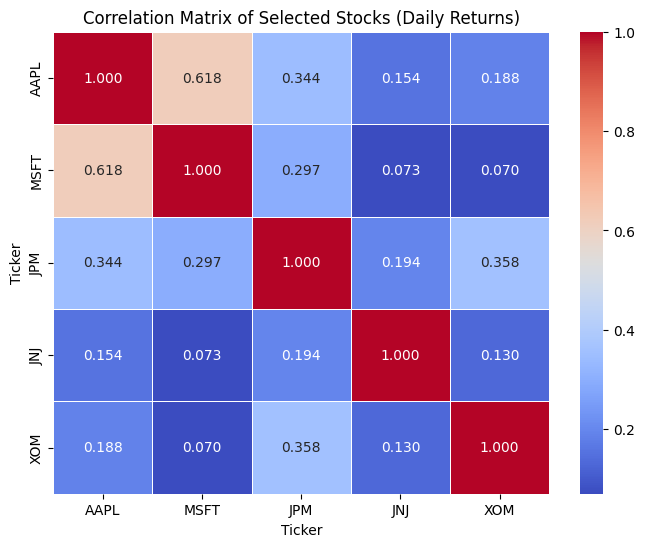


Random Portfolio Weights: [0.133 0.338 0.26  0.213 0.055]
Expected Annual Return: 18.67%
Expected Annual Volatility: 16.29%


In [8]:
# Annualized metrics (252 trading days)
annual_returns = returns[tickers[:5]].mean() * 252
annual_cov = returns[tickers[:5]].cov() * 252

# Display table
metrics_df = pd.DataFrame({
    'Annualized Return (%)': annual_returns * 100,
    'Annualized Volatility (%)': np.sqrt(np.diag(annual_cov)) * 100
})
print("Annualized Return & Volatility (5 stocks):")
print(metrics_df.round(2))

print("\nAnnualized Covariance Matrix:")
print(annual_cov.round(6))

# Correlation heatmap
corr = returns[tickers[:5]].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.5)
plt.title('Correlation Matrix of Selected Stocks (Daily Returns)')
plt.show()

# Basic random portfolio simulation
np.random.seed(42)
rand_weights = np.random.random(5)
rand_weights /= rand_weights.sum()
port_return = np.sum(annual_returns * rand_weights)
port_vol = np.sqrt(rand_weights.T @ annual_cov @ rand_weights)
print(f"\nRandom Portfolio Weights: {np.round(rand_weights, 3)}")
print(f"Expected Annual Return: {port_return*100:.2f}%")
print(f"Expected Annual Volatility: {port_vol*100:.2f}%")